# 🧬 Notebook 06: Functional Enrichment Analysis (GSEA & GO/KEGG)

## 📌 Step 1: Preparing the Ranked Gene List
Standard Over-Representation Analysis (ORA) requires a large set of strictly significant DEGs. Since our strict filtering yielded only 2 DEGs, we will utilize **Gene Set Enrichment Analysis (GSEA)**. 

GSEA does not rely on an arbitrary threshold. Instead, it evaluates microarray or RNA-Seq data at the level of gene sets. We will rank our entire dataset (3,964 genes) using a metric that combines both statistical significance and effect size: 
**Ranking Metric** = $-\log_{10}(\text{p-value}) \times \text{sign}(\log_{2}\text{FoldChange})$

In [2]:
import pandas as pd
import numpy as np
import os

print("📊 Preparing Ranked Gene List for GSEA...")

# 1. Load the full statistical results from DESeq2 (we need to save this from Notebook 5 if not done)
# Assuming you have the full res_df available, or we load it. 
# (Note: make sure you exported the full res_df to CSV in the previous notebook, or we can just reconstruct it here)
# For this script, let's load the full results from Notebook 5:
file_path = 'results/count_matrix/full_deseq2_results.csv'

try:
    res_df = pd.read_csv(file_path, index_col=0)
except FileNotFoundError:
    print(f"⚠️ Error: {file_path} not found. Make sure to export the FULL res_df from Notebook 05 first.")

# 2. Drop genes with NaN p-values to avoid calculation errors
res_clean = res_df.dropna(subset=['pvalue', 'log2FoldChange']).copy()

# 3. Calculate the ranking metric: -log10(pvalue) * sign(log2FC)
# We add a tiny number (1e-300) to p-values of 0 to avoid log(0) errors
res_clean['pvalue'] = res_clean['pvalue'].replace(0, 1e-300)
res_clean['score'] = (-np.log10(res_clean['pvalue'])) * np.sign(res_clean['log2FoldChange'])

# 4. Sort genes based on the score (descending order)
ranked_genes = res_clean[['score']].sort_values(by='score', ascending=False)

# 5. Save the ranked list for GSEA (.rnk format is standard)
os.makedirs('results/enrichment', exist_ok=True)
ranked_genes.to_csv('results/enrichment/gene_ranking.rnk', sep='\t', header=False)

print(f"✅ Successfully ranked {len(ranked_genes)} genes.")
print("\n🔝 Top 5 Up-regulated genes (by score):")
print(ranked_genes.head())
print("\n🔻 Top 5 Down-regulated genes (by score):")
print(ranked_genes.tail())

📊 Preparing Ranked Gene List for GSEA...
✅ Successfully ranked 3964 genes.

🔝 Top 5 Up-regulated genes (by score):
            score
Geneid           
Rv0341  10.024416
Rv0342   5.506273
Rv2371   4.322319
Rv1653   4.151834
Rv1656   3.801529

🔻 Top 5 Down-regulated genes (by score):
            score
Geneid           
Rv1251c -4.918554
Rv3150  -5.007467
Rv1884c -5.048456
Rv3148  -5.212229
Rv0099  -8.038105


## 🏃‍♂️ Step 2: Running Preranked GSEA

With our ranked gene list ready, we will perform **Preranked Gene Set Enrichment Analysis (GSEA)** using the `gseapy` library. 
Since *Mycobacterium tuberculosis* is a non-model organism, standard human/mouse databases (like MSigDB) cannot be used directly. We will configure `gseapy` to use the appropriate KEGG pathways for our organism.

In [4]:
import gseapy as gp
import requests
import os
import pandas as pd

print("🌐 1. Fetching Mycobacterium tuberculosis (H37Rv) pathways from KEGG API...")

# Fetch pathway names
pathway_names_res = requests.get("http://rest.kegg.jp/list/pathway/mtu")
pathway_names = {}
for line in pathway_names_res.text.strip().split('\n'):
    if line:
        parts = line.split('\t')
        path_id = parts[0].replace('path:', '')
        # Clean the name (remove the organism suffix)
        path_name = parts[1].split(' - ')[0] 
        pathway_names[path_id] = path_name

# Fetch gene-to-pathway links
pathway_links_res = requests.get("http://rest.kegg.jp/link/pathway/mtu")
mtu_gene_sets = {}
for line in pathway_links_res.text.strip().split('\n'):
    if line:
        parts = line.split('\t')
        gene_id = parts[0].replace('mtu:', '')
        path_id = parts[1].replace('path:', '')
        
        if path_id in pathway_names:
            path_name = pathway_names[path_id]
            if path_name not in mtu_gene_sets:
                mtu_gene_sets[path_name] = []
            mtu_gene_sets[path_name].append(gene_id)

print(f"✅ Successfully built custom gene sets: {len(mtu_gene_sets)} M.tb pathways loaded!")

print("\n🏃‍♂️ 2. Running Preranked GSEA with M.tb specific pathways...")

rnk_file = 'results/enrichment/gene_ranking.rnk'
out_dir = 'results/enrichment/gsea_kegg_mtu'

try:
    # Run preranked GSEA using our custom dictionary (mtu_gene_sets)
    pre_res = gp.prerank(
        rnk=rnk_file,
        gene_sets=mtu_gene_sets, # 🌟 We passed the custom bacterial dictionary here!
        threads=4,
        min_size=5,
        max_size=500,
        permutation_num=1000, 
        outdir=out_dir,
        seed=42,
        verbose=True
    )
    
    print("\n🎉 GSEA successfully completed!")
    
    # Display the top enriched pathways
    print("\n🔝 Top Enriched Pathways:")
    display(pre_res.res2d.head(10))

except Exception as e:
    print(f"\n⚠️ Encountered an issue during GSEA execution: {e}")

🌐 1. Fetching Mycobacterium tuberculosis (H37Rv) pathways from KEGG API...


2026-06-28 20:38:53,966 [INFO] Parsing data files for GSEA.............................
2026-06-28 20:38:53,973 [INFO] 0030 gene_sets have been filtered out when max_size=500 and min_size=5
2026-06-28 20:38:53,973 [INFO] 0113 gene_sets used for further statistical testing.....
2026-06-28 20:38:53,974 [INFO] Start to run GSEA...Might take a while..................


✅ Successfully built custom gene sets: 143 M.tb pathways loaded!

🏃‍♂️ 2. Running Preranked GSEA with M.tb specific pathways...


2026-06-28 20:39:01,251 [INFO] Congratulations. GSEApy runs successfully................




🎉 GSEA successfully completed!

🔝 Top Enriched Pathways:


,Name,Term,ES,NES,NOM p-val,FDR q-val,FWER p-val,Tag %,Gene %,Lead_genes
0,prerank,Oxidative phosphorylation,-0.667830,-2.076406,0.000000,0.003338,0.003,13/49,3.13%,Rv3148;Rv3150;Rv3147;Rv3149;Rv3145;Rv3146;Rv31...
1,prerank,Tuberculosis,-0.662475,-1.941906,0.001739,0.012239,0.021,23/34,23.74%,Rv3017c;Rv3310;Rv1270c;Rv0934;Rv3874;Rv3890c;R...
2,prerank,Arginine biosynthesis,0.664308,1.804591,0.006316,0.143794,0.132,10/23,13.14%,Rv1653;Rv1656;Rv1652;Rv1655;Rv1384;Rv2222c;Rv1...
3,prerank,Homologous recombination,-0.660552,-1.775649,0.001773,0.066760,0.152,8/22,11.73%,Rv3715c;Rv1547;Rv0054;Rv3711c;Rv2737c;Rv2594c;...
4,prerank,Quorum sensing,-0.625924,-1.712975,0.005405,0.101808,0.275,9/24,14.15%,Rv2349c;Rv2351c;Rv2350c;Rv3921c;Rv3432c;Rv3664...
5,prerank,Sulfur relay system,-0.638623,-1.710147,0.003876,0.083005,0.281,7/22,15.04%,Rv3119;Rv3109;Rv0868c;Rv0866;Rv1335;Rv2291;Rv3...
6,prerank,Citrate cycle (TCA cycle),-0.588513,-1.676560,0.007055,0.097729,0.365,10/29,16.42%,Rv0951;Rv1475c;Rv2241;Rv0952;Rv0896;Rv1098c;Rv...
7,prerank,Ether lipid metabolism,-0.910031,-1.673933,0.001938,0.086311,0.372,4/5,6.46%,Rv2349c;Rv2251;Rv2351c;Rv2350c
8,prerank,Peroxisome,-0.723499,-1.609043,0.021401,0.148401,0.593,5/11,14.66%,Rv2251;Rv0432;Rv2187;Rv0066c;Rv3846
9,prerank,Ribosome,-0.479839,-1.588612,0.007105,0.158245,0.657,19/61,19.05%,Rv0709;Rv0710;Rv0652;Rv0723;Rv0056;Rv3458c;Rv3...


🎨 Generating Enrichment Plots for Top Pathways...
📉 Saved plot for: Oxidative phosphorylation


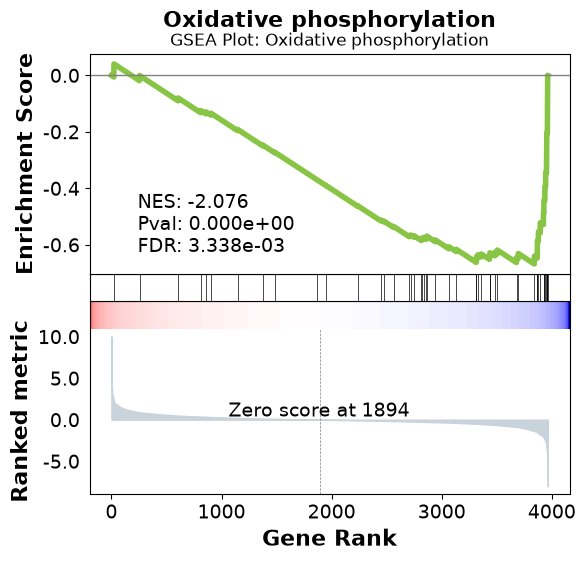

📈 Saved plot for: Arginine biosynthesis


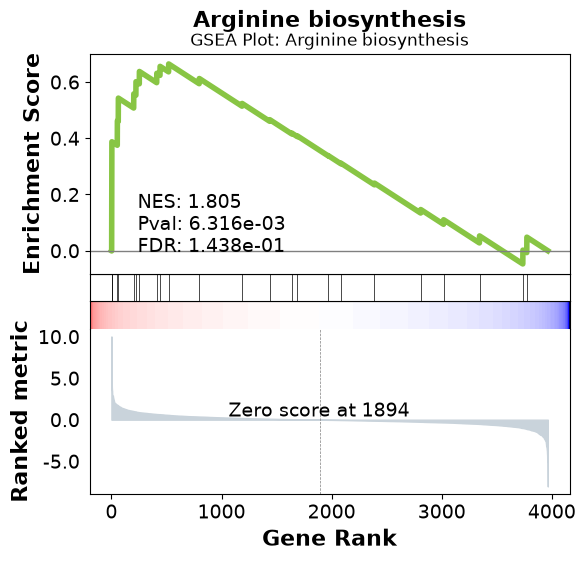

In [5]:
import matplotlib.pyplot as plt

print("🎨 Generating Enrichment Plots for Top Pathways...")

# Get the terms for the plots
# 1. Most significant down-regulated pathway (Oxidative phosphorylation)
down_pathway = "Oxidative phosphorylation"
# 2. Most significant up-regulated pathway (Arginine biosynthesis)
up_pathway = "Arginine biosynthesis"

# Plot the down-regulated pathway
terms = pre_res.res2d.index
if down_pathway in pre_res.res2d['Term'].values:
    gseaplot = gp.plot.gseaplot(rank_metric=pre_res.ranking, term=down_pathway, **pre_res.results[down_pathway])
    plt.title(f'GSEA Plot: {down_pathway}')
    plt.savefig('results/enrichment/gsea_down_plot.png', dpi=300, bbox_inches='tight')
    print(f"📉 Saved plot for: {down_pathway}")
    plt.show()

# Plot the up-regulated pathway
if up_pathway in pre_res.res2d['Term'].values:
    gseaplot = gp.plot.gseaplot(rank_metric=pre_res.ranking, term=up_pathway, **pre_res.results[up_pathway])
    plt.title(f'GSEA Plot: {up_pathway}')
    plt.savefig('results/enrichment/gsea_up_plot.png', dpi=300, bbox_inches='tight')
    print(f"📈 Saved plot for: {up_pathway}")
    plt.show()